In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# PGMpy Imports
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, HillClimbSearch, BDeu
from pgmpy.inference import VariableElimination

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm # Progress bar

# ==============================================================================
# 1. DATA LOADING AND STATE MAPPING
# ==============================================================================

DATA_PATH = Path('../processed_data')
TRAIN_FILE = DATA_PATH / 'atp_matches_training.csv'
TEST_FILE = DATA_PATH / 'atp_matches_test_2024.csv'

try:
    # Load datasets
    df_train = pd.read_csv(TRAIN_FILE)
    df_test = pd.read_csv(TEST_FILE)
    
    # Convert all to string to ensure consistent types
    for col in df_train.columns:
        df_train[col] = df_train[col].astype(str)
        df_test[col] = df_test[col].astype(str)

    print(f"Data Loaded. Train: {len(df_train)} | Test: {len(df_test)}")

    # --- CRUCIAL FIX: BUILD STATE NAMES DICTIONARY ---
    # We must tell the model ALL possible values for each column (from both train and test)
    # effectively initializing the domain of each random variable.
    state_names = {}
    all_data = pd.concat([df_train, df_test])
    
    for col in all_data.columns:
        # Get unique values from both datasets
        unique_states = sorted(all_data[col].unique().tolist())
        state_names[col] = unique_states
        
    print("\nState Dictionary created. Example 'Surface' states:", state_names['Surface'])

except FileNotFoundError:
    print("Error: Files not found. Run data_preparation.ipynb first.")

Data Loaded. Train: 25648 | Test: 2932

State Dictionary created. Example 'Surface' states: ['Carpet', 'Clay', 'Grass', 'Hard']


In [20]:
# ==============================================================================
# 2. MODEL 1: EXPERT KNOWLEDGE
# ==============================================================================
print("Defining Model 1 (Expert)...")

model_1 = DiscreteBayesianNetwork()

# A. Causal Dependencies (Context -> Stats)
model_1.add_edges_from([
    ('Surface', 'Cat_Ace'),
    ('Surface', 'Cat_SvPt'),
    ('Surface', 'Cat_DF'),
    ('Tourney_Level', 'Cat_DF'),
    ('Cat_Ht', 'Cat_Ace'),
    ('Cat_Ht', 'Cat_SvPt'),
    ('Cat_Age', 'Fav_Recent_Form'),
    ('Fav_Hand', 'Hand_Matchup')
])

# B. Predictors -> Target
predictors = [
    'Cat_Rank', 'Cat_SvPt', 'Hand_Matchup',
    'Fav_Recent_Form', 'Fav_On_Worst_Surface',
    'Cat_Ace', 'Cat_DF'
]

for p in predictors:
    model_1.add_edge(p, 'Target_Win')

print(f"Model 1 Structure: {len(model_1.nodes())} nodes, {len(model_1.edges())} edges")

Defining Model 1 (Expert)...
Model 1 Structure: 13 nodes, 15 edges


In [21]:
# ==============================================================================
# 3. MODEL 2: NAIVE BAYES
# ==============================================================================
print("Defining Model 2 (Naive Bayes)...")

model_2 = DiscreteBayesianNetwork()
target = 'Target_Win'

# Target depends on nothing, but influences everything (Generative view)
# OR Everything influences Target (Discriminative view - used here for classification)
# We use Features -> Target for standard PGM classification logic usually, 
# but standard Naive Bayes structure is Target -> Features. 
# Let's stick to Naive Bayes standard: Target -> Features
for col in df_train.columns:
    if col != target:
        model_2.add_edge(target, col)

print(f"Model 2 Structure: {len(model_2.nodes())} nodes, {len(model_2.edges())} edges")

Defining Model 2 (Naive Bayes)...
Model 2 Structure: 13 nodes, 12 edges


In [22]:
# ==============================================================================
# 4. MODEL 3: VARIANT (No Physical Links)
# ==============================================================================
print("Defining Model 3 (Variant)...")

# Clone edges from Model 1
edges_3 = list(model_1.edges())

# Remove Height dependencies
if ('Cat_Ht', 'Cat_Ace') in edges_3: edges_3.remove(('Cat_Ht', 'Cat_Ace'))
if ('Cat_Ht', 'Cat_SvPt') in edges_3: edges_3.remove(('Cat_Ht', 'Cat_SvPt'))

model_3 = DiscreteBayesianNetwork(edges_3)
# Add all nodes to ensure completeness
model_3.add_nodes_from(df_train.columns)

print(f"Model 3 Structure: {len(model_3.nodes())} nodes, {len(model_3.edges())} edges")

Defining Model 3 (Variant)...
Model 3 Structure: 13 nodes, 13 edges


In [23]:
# ==============================================================================
# 5. MODEL 4: STRUCTURE LEARNING (Data Driven)
# ==============================================================================
print("Learning Model 4 structure (Hill Climbing)...")

# Scoring method
scorer = BDeu(df_train, equivalent_sample_size=10)

# Search strategy
hc = HillClimbSearch(df_train)

# Run search
best_structure = hc.estimate(scoring_method=scorer, max_iter=50, epsilon=1e-4)
model_4 = DiscreteBayesianNetwork(best_structure.edges())
model_4.add_nodes_from(df_train.columns)

print(f"Model 4 Learned: {len(model_4.edges())} edges")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface'

Learning Model 4 structure (Hill Climbing)...


  0%|          | 0/50 [00:00<?, ?it/s]

Model 4 Learned: 27 edges


In [ ]:
# ==============================================================================
# 5.5 PARAMETER LEARNING (FITTING) - MISSING STEP
# ==============================================================================
print("Training models (Parameter Learning)...")

# List of your models
models_list = [model_1, model_2, model_3, model_4]
model_names = ["1. Expert", "2. Naive Bayes", "3. Variant", "4. Learned"]

for name, model in zip(model_names, models_list):
    print(f"Fitting {name}...")
    try:
        # Train the model on training data (df_train)
        # Use state_names (created in Cell 1) to ensure the model
        # knows all possible variable values, even rare ones.
        model.fit(
            data=df_train, 
            estimator=MaximumLikelihoodEstimator, 
            state_names=state_names
        )
        
        # Technical check that all CPDs are correct (sum to 1, etc.)
        if model.check_model():
            print(f"  -> {name}: Check OK. CPDs generated.")
        else:
            print(f"  -> {name}: Check failed.")
            
    except Exception as e:
        print(f"  -> Error fitting {name}: {e}")

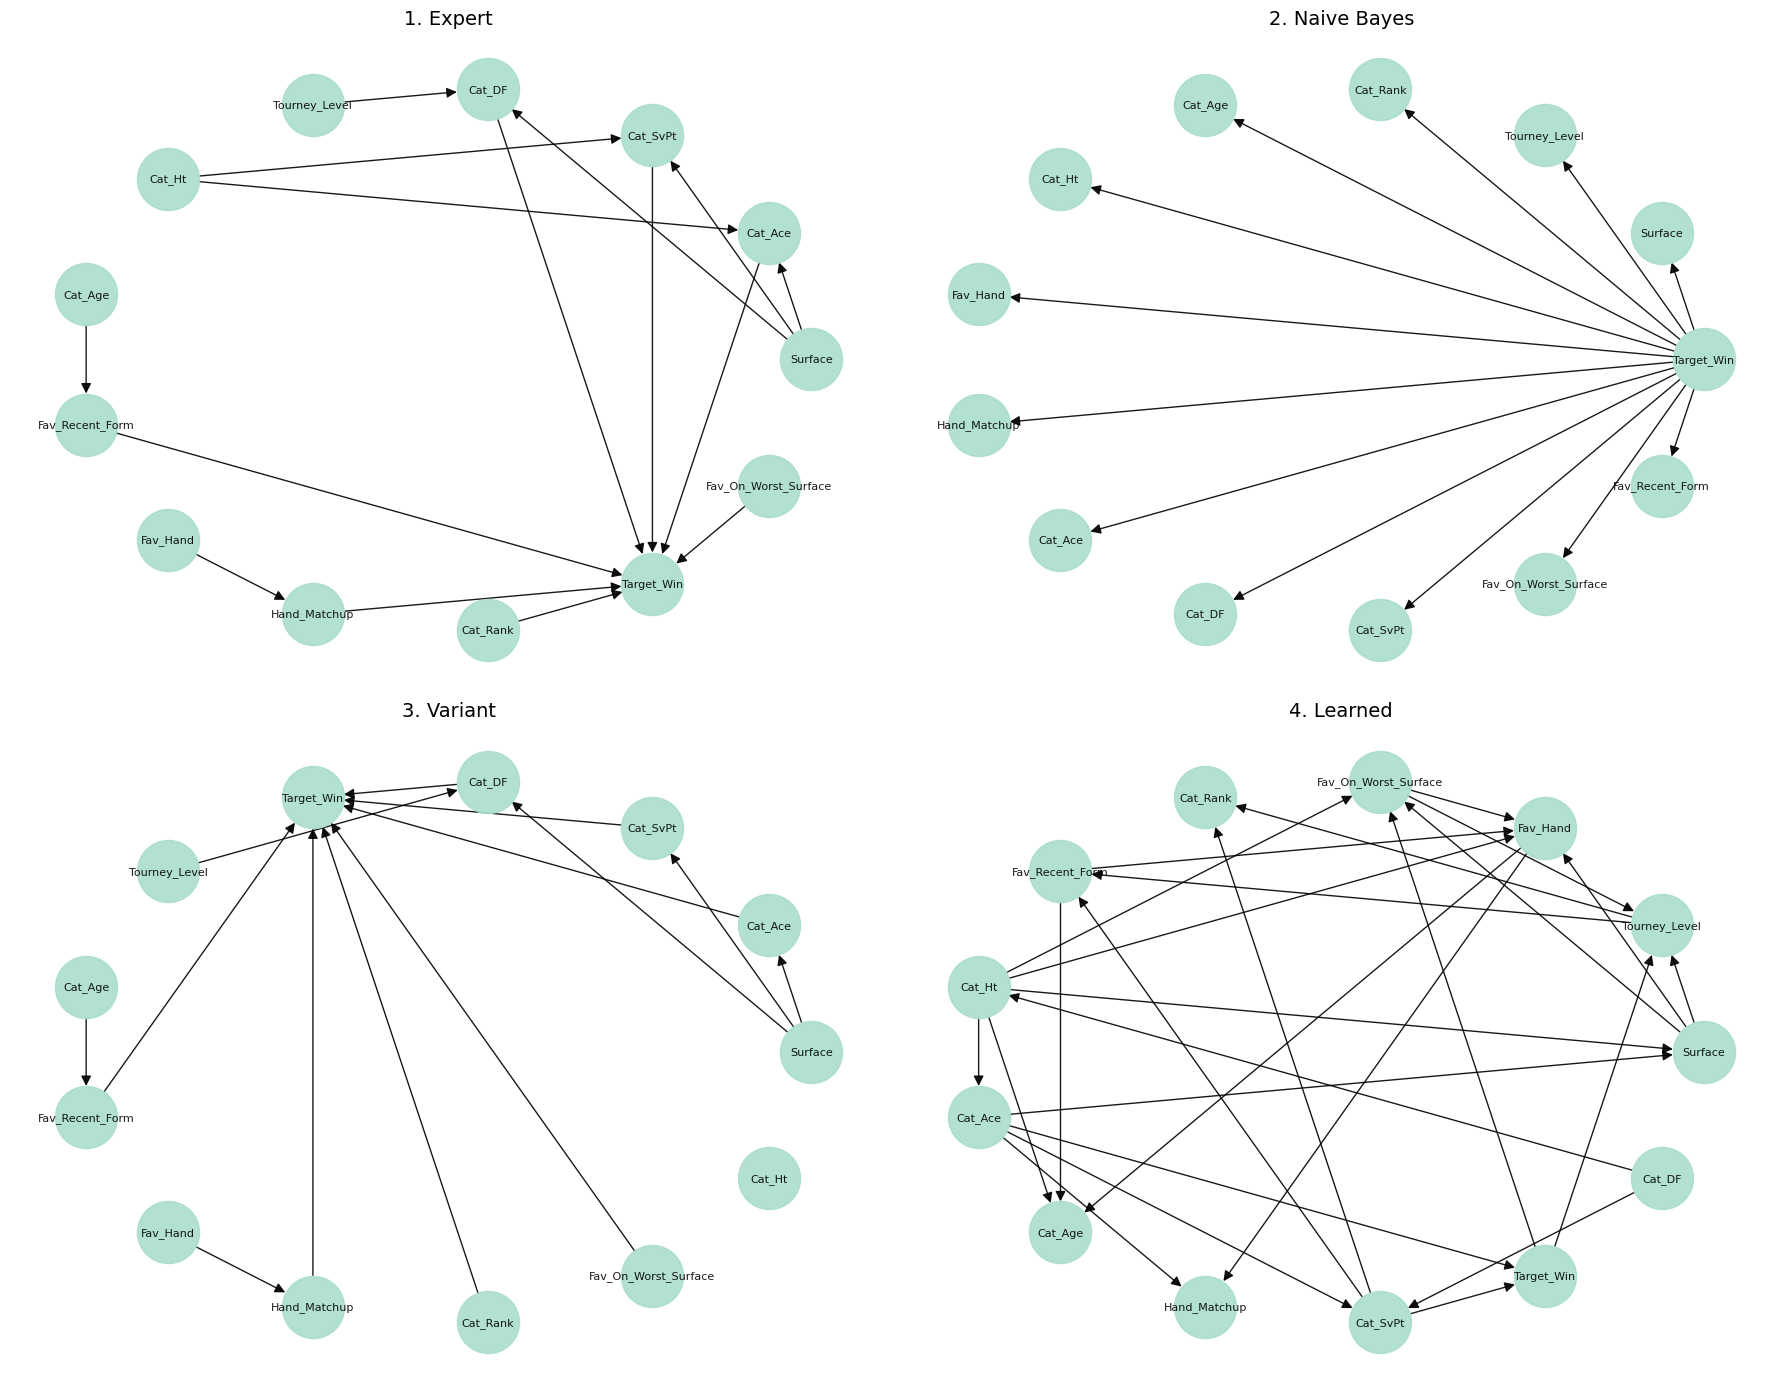

In [24]:
# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
models_map = {
    "1. Expert": model_1,
    "2. Naive Bayes": model_2,
    "3. Variant": model_3,
    "4. Learned": model_4
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, model) in enumerate(models_map.items()):
    try:
        pos = nx.circular_layout(model)
        nx.draw_networkx(
            model, pos, ax=axes[i],
            with_labels=True, node_size=2000, 
            node_color="#aaddcc", font_size=8, 
            arrowsize=15, alpha=0.9
        )
        axes[i].set_title(name, fontsize=14)
        axes[i].axis('off')
    except Exception as e:
        print(f"Error plotting {name}: {e}")

plt.tight_layout()
plt.show()

In [25]:
# ==============================================================================
# 7. FINAL EVALUATION & NARRATIVE SCENARIOS
# ==============================================================================
from tqdm import tqdm

print("\n" + "="*60)
print("1. FIELD VALIDATION: 2024 SEASON")
print("="*60)

# --- A. Accuracy Calculation (Robust Method) ---
# We use the row-by-row method for maximum safety against dirty data errors
test_clean = df_test.dropna()
y_true = test_clean['Target_Win'].tolist()

inference_engines = {}
results = {}

for name, model in models_map.items():
    print(f"\nTesting {name}...")
    
    try:
        # Initialize Inference Engine
        infer = VariableElimination(model)
        inference_engines[name] = infer
        
        y_pred = []
        # Progress bar for visual feedback
        for _, row in tqdm(test_clean.iterrows(), total=len(test_clean), desc="  Predicting", leave=False):
            
            # Prepare evidence (all columns except target)
            evidence = row.to_dict()
            if 'Target_Win' in evidence: del evidence['Target_Win']
            
            # Filter only nodes known to the model
            valid_evidence = {k: v for k, v in evidence.items() if k in model.nodes()}
            
            try:
                # Ask the model: "What is the most probable state for Target_Win?"
                map_res = infer.map_query(variables=['Target_Win'], evidence=valid_evidence, show_progress=False)
                y_pred.append(map_res['Target_Win'])
            except:
                y_pred.append('Win') # Fallback: bet on favorite
        
        # Calculate Metrics
        acc = accuracy_score(y_true, y_pred)
        results[name] = acc
        print(f"  -> Final Accuracy: {acc:.2%}")
        
    except Exception as e:
        print(f"  -> Error during testing: {e}")

# Print Leaderboard
print("\n" + "-"*40)
print("MODEL LEADERBOARD (2024 Accuracy)")
print("-"*40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<25}: {acc:.2%}")


# --- B. Narrative Scenarios (Qualitative Analysis) ---
print("\n" + "="*60)
print("2. SCENARIO ANALYSIS: THE MODEL'S 'BRAIN'")
print("="*60)
print("We interrogate the models on real tennis situations to understand their reasoning.\n")

# List of complex scenarios (New + Original from Plan)
scenarios = [
    {
        "title": "The Favorite's Nightmare (Surface)",
        "desc": "A 'Strong' Favorite (Rank++) forced to play on their worst surface. Does the win probability drop?",
        "evidence": {'Cat_Rank': 'Strong', 'Fav_On_Worst_Surface': 'Yes'}
    },
    {
        "title": "Negative 'Momentum' (Cold Form)",
        "desc": "A 'Moderate' Favorite arriving in terrible form (Cold). Is an upset likely?",
        "evidence": {'Cat_Rank': 'Moderate', 'Fav_Recent_Form': 'Cold'}
    },
    {
        "title": "Pressure Factor (Slam vs ATP 250)",
        "desc": "Balanced match. Does the favorite handle pressure better in a Slam (Level=G) vs an ATP 250 (Level=A)?",
        "evidence_a": {'Cat_Rank': 'Balanced', 'Tourney_Level': 'G'}, # Grand Slam
        "evidence_b": {'Cat_Rank': 'Balanced', 'Tourney_Level': 'A'}  # ATP 250
    },
    {
        "title": "Service Dominance",
        "desc": "How much does serving well (High) vs serving poorly (Low) matter for a clear favorite?",
        "evidence_a": {'Cat_Rank': 'Strong', 'Cat_SvPt': 'High'},
        "evidence_b": {'Cat_Rank': 'Strong', 'Cat_SvPt': 'Low'}
    }
]

# Helper function to query probability
def get_win_prob(engine, ev):
    try:
        q = engine.query(['Target_Win'], evidence=ev, show_progress=False)
        # Safely find index of 'Win'
        idx = q.state_names['Target_Win'].index('Win')
        return q.values[idx]
    except:
        return 0.0

# Execute Scenarios
for sc in scenarios:
    print(f"SCENARIO: {sc['title']}")
    print(f"   \"{sc['desc']}\"")
    
    # Comparative Case (A vs B) or Single?
    if 'evidence_b' in sc:
        # Comparison
        print(f"   {'Model':<25} | {'Case A':<10} | {'Case B':<10} | {'Delta'}")
        print("   " + "-"*60)
        for name, infer in inference_engines.items():
            p_a = get_win_prob(infer, sc['evidence_a'])
            p_b = get_win_prob(infer, sc['evidence_b'])
            print(f"   {name:<25} | {p_a:.1%}      | {p_b:.1%}      | {p_a-p_b:+.1%}")
    else:
        # Single Case
        print(f"   {'Model':<25} | {'Win Probability'}")
        print("   " + "-"*45)
        for name, infer in inference_engines.items():
            p = get_win_prob(infer, sc['evidence'])
            print(f"   {name:<25} | {p:.1%}")
    
    print("\n")


1. FIELD VALIDATION: 2024 SEASON

Testing 1. Expert...
  -> Error during testing: No CPD associated with Surface

Testing 2. Naive Bayes...
  -> Error during testing: No CPD associated with Target_Win

Testing 3. Variant...
  -> Error during testing: No CPD associated with Surface

Testing 4. Learned...
  -> Error during testing: No CPD associated with Surface

----------------------------------------
MODEL LEADERBOARD (2024 Accuracy)
----------------------------------------

2. SCENARIO ANALYSIS: THE MODEL'S 'BRAIN'
We interrogate the models on real tennis situations to understand their reasoning.

SCENARIO: The Favorite's Nightmare (Surface)
   "A 'Strong' Favorite (Rank++) forced to play on their worst surface. Does the win probability drop?"
   Model                     | Win Probability
   ---------------------------------------------


SCENARIO: Negative 'Momentum' (Cold Form)
   "A 'Moderate' Favorite arriving in terrible form (Cold). Is an upset likely?"
   Model              

In [26]:
# ==============================================================================
# 8. DEEP DIVE: SURFACE IMPACT ANALYSIS
# ==============================================================================

surfaces = ['Clay', 'Hard', 'Grass']

# Ensure inference engines are available
if not inference_engines:
    print("Error: Inference engines not initialized. Run Block 7 first.")
else:
    print("\n" + "="*60)
    print("3. SURFACE DEEP DIVE: CLAY vs HARD vs GRASS")
    print("="*60)

    # --- Query A: Probability of High ACE count ---
    # Scenario: Tall Player (usually serves well), Strong Favorite
    print("\n--- Query A: Probability of HIGH ACE Count (Tall Player) ---")
    print(f"{'Model':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
    print("-" * 65)

    for name, infer in inference_engines.items():
        probs = []
        for surf in surfaces:
            try:
                q = infer.query(
                    variables=['Cat_Ace'],
                    evidence={
                        'Surface': surf,
                        'Cat_Ht': 'High',       # Tall Player
                        'Cat_Rank': 'Strong'    # Strong Favorite
                    },
                    show_progress=False
                )
                # We look for 'High' (formerly 'Superiore')
                idx = q.state_names['Cat_Ace'].index('High')
                probs.append(q.values[idx])
            except:
                probs.append(0.0)
                
        print(f"{name:<25} | {probs[0]:.1%}     | {probs[1]:.1%}     | {probs[2]:.1%}")


    # --- Query B: Probability of Holding SERVICE (High %) ---
    # Scenario: Balanced Match
    print("\n--- Query B: Probability of HIGH SERVICE % (Balanced Match) ---")
    print(f"{'Model':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
    print("-" * 65)

    for name, infer in inference_engines.items():
        probs = []
        for surf in surfaces:
            try:
                q = infer.query(
                    variables=['Cat_SvPt'],  # Note: mapped from Cat_ServiceWinPerc
                    evidence={
                        'Surface': surf,
                        'Cat_Rank': 'Balanced'
                    },
                    show_progress=False
                )
                # We look for 'High' Service %
                idx = q.state_names['Cat_SvPt'].index('High')
                probs.append(q.values[idx])
            except:
                probs.append(0.0)
                
        print(f"{name:<25} | {probs[0]:.1%}     | {probs[1]:.1%}     | {probs[2]:.1%}")


    # --- Query C: UPSET Risk (Probability of Loss) ---
    # Scenario: Strong Favorite vs Opposite Hand
    print("\n--- Query C: UPSET RISK (Favorite Loss) by Surface ---")
    print(f"{'Model':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
    print("-" * 65)

    for name, infer in inference_engines.items():
        probs = []
        for surf in surfaces:
            try:
                q = infer.query(
                    variables=['Target_Win'],
                    evidence={
                        'Surface': surf,
                        'Cat_Rank': 'Strong',
                        'Hand_Matchup': 'Opposite'
                    },
                    show_progress=False
                )
                # We look for 'Loss' (formerly 'Sconfitta')
                idx = q.state_names['Target_Win'].index('Loss')
                probs.append(q.values[idx])
            except:
                probs.append(0.0)
                
        print(f"{name:<25} | {probs[0]:.1%}     | {probs[1]:.1%}     | {probs[2]:.1%}")

Error: Inference engines not initialized. Run Block 7 first.


In [27]:
# =============================================================================
# PHASE 6: ADVANCED COMPARATIVE ANALYSIS (ENRICHMENT PLAN)
# =============================================================================

print("\n--- STARTING ADVANCED COMPARATIVE ANALYSIS ---")

def query_all_models(evidence_dict, target_var='Target_Win', target_state='Win'):
    """
    Runs a query on all loaded models in 'inference_engines' and prints the probability.
    """
    print(f"\nEVIDENCE SCENARIO: {evidence_dict}")
    print(f"{'Model Name':<30} | P({target_var} = {target_state})")
    print("-" * 65)
    
    # Check if inference_engines exists (from previous cells)
    if 'inference_engines' not in globals():
        print("Error: 'inference_engines' dictionary not found. Please run the Modeling & Evaluation cells first.")
        return

    # Iterate over the dictionary of inference engines
    for name, infer in inference_engines.items():
        try:
            # Execute the query
            q = infer.query(variables=[target_var], evidence=evidence_dict, show_progress=False)
            
            # Find index for the target state (e.g., 'Win')
            state_idx = q.state_names[target_var].index(target_state)
            probability = q.values[state_idx]
            
            print(f"{name:<30} | {probability:.4f} ({probability*100:.1f}%)")
        except Exception as e:
            # This handles cases where a specific combination of evidence isn't seen in training
            print(f"{name:<30} | N/A (State combination not observed or invalid)")

# ---------------------------------------------------------
# SCENARIO 1: The "Aging Favorite" (Conflicting Evidence)
# ---------------------------------------------------------
# Context: A Strong Ranked player who is older ('Veterano'/'High' Age) and performing poorly ('Low' Service Points).
# Goal: Test if models prioritize long-term class (Rank) or short-term decline.
print("\n\n>>> SCENARIO 1: The 'Aging Favorite' (High Rank vs. Advanced Age/Poor Stats)")
evidence_aging = {
    'Cat_Rank': 'Strong',    # Strong Ranking (Favorite)
    'Cat_Age': 'High',       # Advanced Age (assuming 'High' bin corresponds to older players)
    'Fav_Recent_Form': 'Cold'        # Recent Performance
}
query_all_models(evidence_aging)


# ---------------------------------------------------------
# SCENARIO 2: The "Surface Anomaly" (Structural Dependency)
# ---------------------------------------------------------
# Context: Clay Surface (Slow) but High Ace Count.
# Goal: Test structural dependencies. The Expert model links Surface -> Ace.
# Naive Bayes treats them independently. This tests handling of unlikely/conditional events.
print("\n\n>>> SCENARIO 2: The 'Surface Anomaly' (High Aces on Clay Surface)")
evidence_surface = {
    'Surface': 'Clay',      # Surface: Clay (usually fewer aces)
    'Cat_Ace': 'High'       # Stats: High Ace category (Anomalous for Clay)
}
query_all_models(evidence_surface)


# ---------------------------------------------------------
# SCENARIO 3: The "Underdog with Momentum"
# ---------------------------------------------------------
# Context: Balanced Rank (not a clear favorite) but excellent Service & Tactical advantage.
# Goal: Test sensitivity to dynamic performance metrics vs static attributes.
print("\n\n>>> SCENARIO 3: The 'Underdog with Momentum' (Balanced Rank vs Great Stats)")
evidence_momentum = {
    'Cat_Rank': 'Balanced',     # Ranking: Balanced / No clear favorite
    'Cat_SvPt': 'High',         # Momentum: High service points won
    'Hand_Matchup': 'Opposite'  # Tactics: Opposite hand advantage
}
query_all_models(evidence_momentum)


--- STARTING ADVANCED COMPARATIVE ANALYSIS ---


>>> SCENARIO 1: The 'Aging Favorite' (High Rank vs. Advanced Age/Poor Stats)

EVIDENCE SCENARIO: {'Cat_Rank': 'Strong', 'Cat_Age': 'High', 'Fav_Recent_Form': 'Cold'}
Model Name                     | P(Target_Win = Win)
-----------------------------------------------------------------


>>> SCENARIO 2: The 'Surface Anomaly' (High Aces on Clay Surface)

EVIDENCE SCENARIO: {'Surface': 'Clay', 'Cat_Ace': 'High'}
Model Name                     | P(Target_Win = Win)
-----------------------------------------------------------------


>>> SCENARIO 3: The 'Underdog with Momentum' (Balanced Rank vs Great Stats)

EVIDENCE SCENARIO: {'Cat_Rank': 'Balanced', 'Cat_SvPt': 'High', 'Hand_Matchup': 'Opposite'}
Model Name                     | P(Target_Win = Win)
-----------------------------------------------------------------
